# Mid-semester examination 4/4/2026

## Rules for the exam

- Duration of exam: 3 hours.
- Answer all the questions.
- No use of AI agents.
- Open book/open notes/open internet.
- No help from other humans or AI agents.

## Questions

### Question 1

Define a function `flower()` that generates the coordinates of a stylized flower. 
The flower consists of the following components:

1. Petals: 5 petals formed using the polar equation: $r=1+ \frac{sin(5 \theta)}{2}$ for $\theta \in [0,2\pi]$
2. Center: A small circle of radius 0.2 centered at the origin (0,0)
3. Stem: A vertical line from (0,−1) to (0,−2)

**Task**

1. Convert the polar coordinates of the petals into Cartesian coordinates using $x=r \cos\theta, y=r \sin \theta$. (**2 marks**)
2. Generate coordinates for the center using parametric equations of a circle. (**1 mark**)
3. Represent the stem using appropriate linear coordinates (i.e. a suitable straight line). (**2 marks**)
4. Combine all coordinates into two arrays x and y, and return them from the function. To prevent matplotlib from connecting the end of one part of the flower to the start of the next, insert `np.nan` between different parts of the flower. (**2 marks**)
5. Finally, call the function `flower()` and use `plt.plot` to display the flower. (**1 mark**)

Flower


(np.float64(-1.5775789942535026),
 np.float64(1.573319555009629),
 np.float64(-2.1749119388717557),
 np.float64(1.673150716306873))

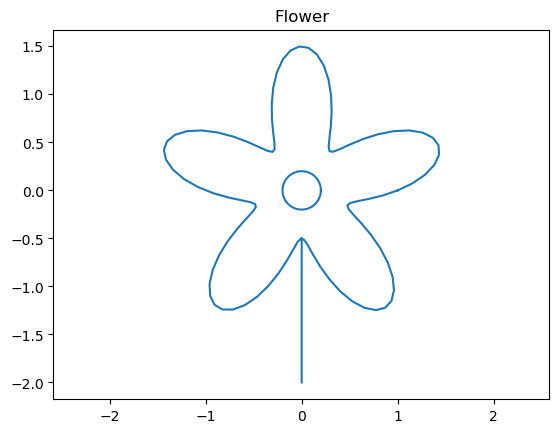

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def flower():
    print("Flower")
    theta = np.linspace(0, 2*np.pi, 100)
    radius = 1 + (np.sin(5 * theta) /2)

    x_petal = radius * np.cos(theta)
    y_petal = radius * np.sin(theta)

    x_center = 0.2 * np.cos(theta)
    y_center = 0.2 * np.sin(theta)

    x_stem = np.zeros(100)
    y_stem = np.linspace(-0.5, -2, 100)

    x = np.concatenate([x_petal, [np.nan], x_center, [np.nan], x_stem])
    y = np.concatenate([y_petal, [np.nan], y_center, [np.nan], y_stem])
    return x, y

x, y = flower()
plt.plot(x, y)
plt.title("Flower")
plt.axis('equal')

### Question 2

Consider the following code using a `for` loop to resample the scores of Virat Kohli to compute the distribution of his average score in a three match series.  Rewrite this using vectorized numpy operations (i.e. without using a `for` loop) using basic numpy features. You can set the random seed to get the same result. Show that you are indeed obtaining the same result by comparing the two arrays using the `np.allclose` function. (**5 marks**)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)
ks = np.loadtxt('data/kohli.txt')

print(ks)
n_exp = 10000
ng = 3
avgs = []
for i in range(n_exp):
    avg = np.mean(np.random.choice(ks, size=ng))
    avgs.append(avg)
    
avgs = np.asarray(avgs)
print(f'avgs: {avgs}')


np.random.seed(123)
ksv = np.random.choice(ks, size=(n_exp, ng))
avgs_vectorized = ksv.mean(axis=1)
print(f'avgs_vecorized: {avgs_vectorized}')

print(f'\nComparing the average of Kohli score using the for loop vs using the numpy vectorized operation')
print(f'Result: {np.allclose(avgs, avgs_vectorized)}')


[ 12.  37.  25.  54.  31.   2.  16.  79.  30.  10.  27.  54. 107.   9.
  91.  71. 102.   2.  31.  57.   0.  82.  18.  68.  11.  18.  10.  28.
   0.   8.  37. 118. 105.  64.  63.   0.   2.  54.  22.  28.  87.   2.
 100.   8.  34.  12.   1.  59.  24.   9.  35.   2.  81.   0.  22.  94.
  55.   9.   7.  16. 107.  37. 112.  35.  86.   0.   3. 117.  20.  23.
  80.  31.  77.  18.  15.  12.  66.  21. 133. 108.  66. 183. 106.   1.
  38. 128.  23.   0.   6.   7.  15.  37.  77.  26.   0.  31.  22.  22.
  58.  43.  11.   2. 102.  31.   2. 115.  14.  68.  61. 100.  68. 115.
   0.  86.  99.  19.  31.   0. 123.  78.   6.   2.  82. 136.  48.   5.
   0.  40.   1.  13.   2.  62. 127.  22.  49.  53.  66. 139.   9.   4.
   3.   8. 107.  46.  33.  33.  44.  38.   3.   1.   1.  23.  25.  11.
  12.  77. 138.   7.  91.  59. 117. 106.   8.  85.   9. 154.  45.  65.
 122.   8.  55.  81.   0.  76.  96.   5.  32.  87.  11.   3. 111.  82.
   4.   3. 131. 110.   0.  92.  28.  21.  39. 121.  29. 113. 112.  46.
 160. 

### Question 3

Look at the ODI bowling scores for Jasprit Bumrah. You can find this information from here: https://stats.espncricinfo.com/ci/engine/player/625383.html?class=2;template=results;type=bowling;view=match

Use a similar approach as done for batsmen to get data from ESPN cricinfo and clean up the dataset to save it into a csv file called `"bumrah_odi_bowling.csv"` for further processing. Make sure the various columns are correctly processed and stored with the appropriate data type. In your code, show that you have done this by showing appropriate information about the data frame. Make suitable plots to substantiate your analysis. (**5 marks**)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from io import StringIO

url = 'https://stats.espncricinfo.com/ci/engine/player/625383.html?class=2;template=results;type=bowling;view=match'

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)"
}

response = requests.get(url, headers=headers)
table = pd.read_html(StringIO(response.text))
df_bumrah = table[0]
df_bumrah.describe()

# Unable to directly download the data from the websit and hence directly copy pasting the data 
# from the site to create a CSV file of the format
# Overs	Mdns	Runs	Wkts	Econ	Ave	SR		Opposition	Ground	Start DateAscending	
# 10.0	0	40	2	4	20	30		v Australia	Sydney	23 Jan 2016	ODI # 3727
# 9.5	2	28	4	2.84	7	14.7		v Zimbabwe	Harare	11 Jun 2016	ODI # 3742
# 6.0	0	27	1	4.5	27	36		v Zimbabwe	Harare	13 Jun 2016	ODI # 3744
# 10.0	1	22	4	2.2	5.5	15		v Zimbabwe	Harare	15 Jun 2016	ODI # 3746

#Reading from the csv data for bumrah
df_bumrah = pd.read_csv('data/bumrah.csv', sep='\t')
df_bumrah.head()

,Overs,Mdns,Runs,Wkts,Econ,Ave,SR,Unnamed: 7,Opposition,Ground,Start DateAscending,Unnamed: 11
0,10.0,0,40,2,4,20,30,NaN,v Australia,Sydney,23 Jan 2016,ODI # 3727
1,9.5,2,28,4,2.84,7,14.7,NaN,v Zimbabwe,Harare,11 Jun 2016,ODI # 3742
2,6.0,0,27,1,4.5,27,36,NaN,v Zimbabwe,Harare,13 Jun 2016,ODI # 3744
3,10.0,1,22,4,2.2,5.5,15,NaN,v Zimbabwe,Harare,15 Jun 2016,ODI # 3746
4,8.0,1,29,0,3.62,-,-,NaN,v New Zealand,Dharamsala,16 Oct 2016,ODI # 3796


In [5]:
import numpy as np
import matplotlib.pyplot as plt

#Removing the overs where Over is not numeric, like --
df_bumrah = df_bumrah[df_bumrah['Overs'].str.replace('.', '', regex=False).str.isnumeric()]
df_bumrah.count()

#Cleaning the data for the column Unnamed, which is not required for the analysis
# df_bumrah.reset_index(drop=True)
# df_bumrah = df_bumrah.drop(columns=['Unnamed: 13'], errors='ignore')
# df_bumrah.head()

print(df_bumrah.columns)
df_bumrah = df_bumrah.drop(columns=['Unnamed: 7'], errors='ignore')
df_bumrah.head()
#df_bumrah = df_bumrah[['Overs', 'Mdns', 'Runs', 'Wkts', 'Econ', 'Ave', 'SR', 'Opposition', 'Ground', 'Start Date' ]]

#Cleaning the data for the column Ave and SR as 0 where the value is -
df_bumrah['Ave'] = pd.to_numeric(df_bumrah['Ave'].replace('-', 0), errors='coerce')
df_bumrah['SR'] = pd.to_numeric(df_bumrah['SR'].replace('-', 0), errors='coerce')
df_bumrah.head()

#Cleaning the data for the opposition column to format v Australia to just Australia and have title case
df_bumrah['Opposition'] = df_bumrah['Opposition'].str.replace('v ', '', regex=False).str.title()
df_bumrah.head()

#Cleaning the date column 
df_bumrah['Start DateAscending'] = pd.to_datetime(df_bumrah['Start DateAscending'], errors='coerce')
df_bumrah = df_bumrah.rename(columns={'Start DateAscending': 'Start Date'})
df_bumrah.head()

Index(['Overs', 'Mdns', 'Runs', 'Wkts', 'Econ', 'Ave', 'SR', 'Unnamed: 7',
       'Opposition', 'Ground', 'Start DateAscending', 'Unnamed: 11'],
      dtype='str')


,Overs,Mdns,Runs,Wkts,Econ,Ave,SR,Opposition,Ground,Start Date,Unnamed: 11
0,10.0,0,40,2,4,20.0,30.0,Australia,Sydney,2016-01-23,ODI # 3727
1,9.5,2,28,4,2.84,7.0,14.7,Zimbabwe,Harare,2016-06-11,ODI # 3742
2,6.0,0,27,1,4.5,27.0,36.0,Zimbabwe,Harare,2016-06-13,ODI # 3744
3,10.0,1,22,4,2.2,5.5,15.0,Zimbabwe,Harare,2016-06-15,ODI # 3746
4,8.0,1,29,0,3.62,0.0,0.0,New Zealand,Dharamsala,2016-10-16,ODI # 3796


Text(0, 0.5, 'wickets')

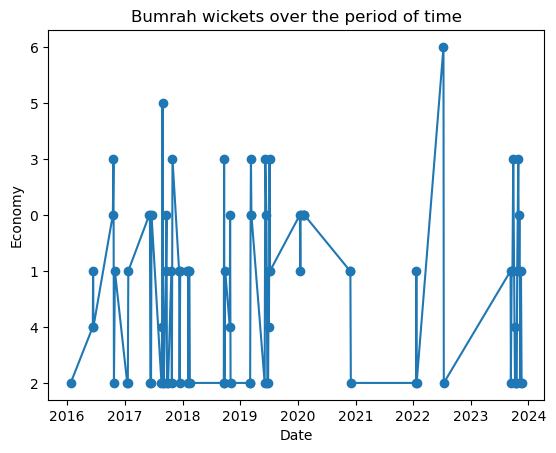

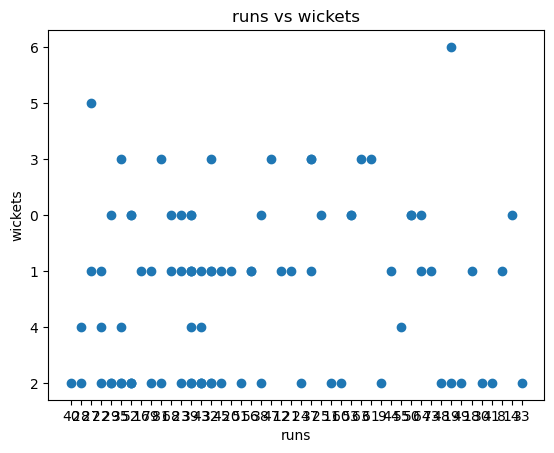

In [6]:
import numpy as np
import matplotlib.pyplot as plt

#Plotting the data after cleaning
plt.figure()

#ploting wickets taken over time
plt.plot(df_bumrah['Start Date'], df_bumrah['Wkts'], marker='o')
plt.title('Bumrah wickets over the period of time')
plt.xlabel('Date')
plt.ylabel('Economy')

#plotting runs vs wickets
plt.figure()
plt.scatter(df_bumrah['Runs'], df_bumrah['Wkts'])
plt.title('runs vs wickets')
plt.xlabel('runs')
plt.ylabel('wickets')

### Question 4

Using Bumrah's bowling scores and the file you have created perform a simple data analysis. This is open ended, but at the bare minimum you must show his performance with respect to economy rate, strike rate and average for different countries and see which countries he has performed best against and worst against. (**5 marks**)

In [7]:
import pandas as pd
df_bumrah['Econ'] = pd.to_numeric(df_bumrah['Econ'], errors='coerce')
df_bumrah['SR'] = pd.to_numeric(df_bumrah['SR'], errors='coerce')
df_bumrah['Ave'] = pd.to_numeric(df_bumrah['Ave'], errors='coerce')

bowling_stats = df_bumrah.groupby('Opposition').agg({
    'Econ': 'mean',
    'SR': 'mean',
    'Ave': 'mean',
    'Wkts': 'sum'
}).reset_index()

print(bowling_stats)

#Best and worst teams
best_economy = bowling_stats.loc[bowling_stats['Econ'].idxmin()]
worst_economy = bowling_stats.loc[bowling_stats['Econ'].idxmax()]

print(f'\nBest economy: {best_economy["Opposition"]}, worst economy: {worst_economy["Opposition"]}')

      Opposition      Econ         SR        Ave                   Wkts
0    Afghanistan  3.900000  22.500000  14.625000                     24
1      Australia  5.286667  26.290476  23.420476  210222203030101121322
2     Bangladesh  4.422000  28.860000  21.016000                  23142
3        England  5.752857  32.557143  32.902857                2211623
4    Netherlands  3.660000  27.000000  16.500000                      2
5    New Zealand  4.762308  27.923077  22.486154          0321123100011
6       Pakistan  4.437143  14.642857   7.642857                0022012
7   South Africa  3.867500  31.750000  21.458333           211211222120
8      Sri Lanka  4.050769  24.461538  16.652308          0245221213211
9    West Indies  2.487500  12.750000   4.687500                   4022
10      Zimbabwe  3.180000  21.900000  13.166667                    414

Best economy: West Indies, worst economy: England



Best strike rate: West Indies, worst strike rate: England

Best average: West Indies, worst average: England


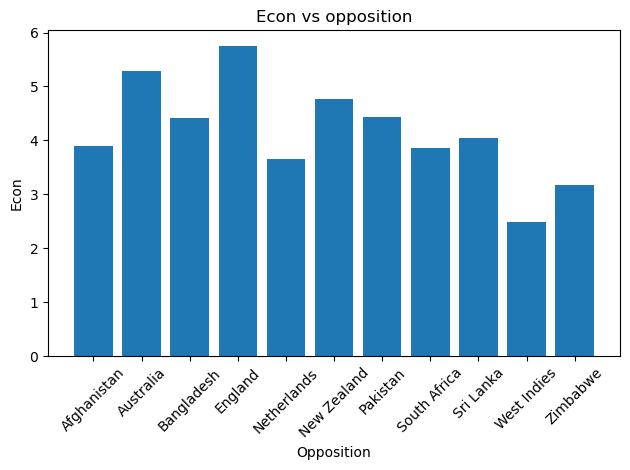

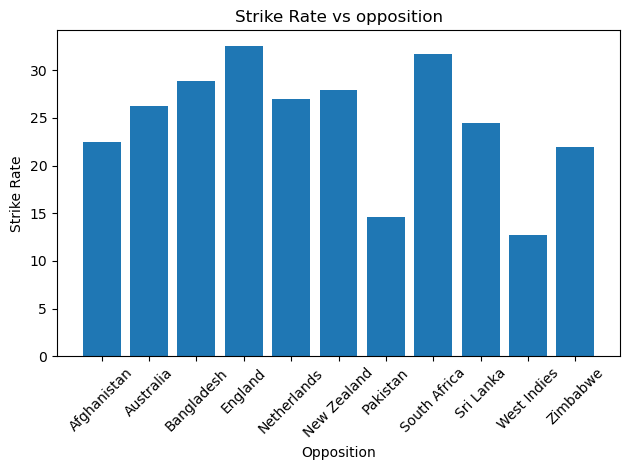

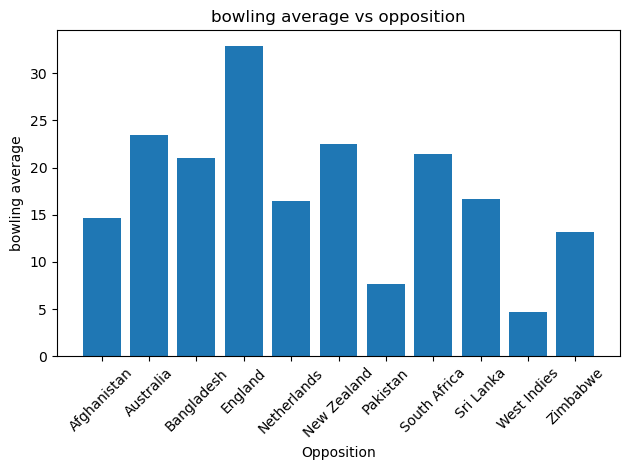

In [8]:
#Best strke rate
best_strikerate = bowling_stats.loc[bowling_stats['SR'].idxmin()]
worst_strikerate = bowling_stats.loc[bowling_stats['SR'].idxmax()]

print(f'\nBest strike rate: {best_strikerate["Opposition"]}, worst strike rate: {worst_strikerate["Opposition"]}')

#Best average
best_average = bowling_stats.loc[bowling_stats['Ave'].idxmin()]
worst_average = bowling_stats.loc[bowling_stats['Ave'].idxmax()]

print(f'\nBest average: {best_average["Opposition"]}, worst average: {worst_average["Opposition"]}')

plt.figure()
plt.bar(bowling_stats['Opposition'], bowling_stats['Econ'])
plt.title('Econ vs opposition')
plt.xlabel('Opposition')
plt.ylabel('Econ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Plotting strike rate vs teams
plt.figure()
plt.bar(bowling_stats['Opposition'], bowling_stats['SR'])
plt.title('Strike Rate vs opposition')
plt.xlabel('Opposition')
plt.ylabel('Strike Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Plotting bowling average vs teams
plt.figure()
plt.bar(bowling_stats['Opposition'], bowling_stats['Ave'])
plt.title('bowling average vs opposition')
plt.xlabel('Opposition')
plt.ylabel('bowling average')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Question 5

Consider the given data file, `"marks.csv"`. It has three columns: the mid-semester marks for a batch of 100 students, their corresponding end-semester marks, and their birth gender (a categorical variable). We expect that there is a linear correlation between the mid-semester and end-semester marks and that gender plays a role as well. Find the coefficients for a linear model using linear regression as follows.

1. Load the csv file using `pandas` into a data frame. Make a scatter plot of the end semester marks versus the mid-semester marks. (**1 mark**)
2. In order to convert the categorical variables into variables for regression recall from the lectures that we can use `pd.get_dummies(data=df, drop_first=True, dtype=float)` to get a suitable data frame (the use of the `dtype=float` is not necessary but important later on in this question). Do this for your data frame and look at the resulting data frame. Comment on what has changed in this new data frame from your original. (**1 mark**)
3. Now drop the end semester marks from the previous data frame (this is super important), using `df.drop(...)` to create the input features for the linear model and store in a variable `X`. Check that this new data frame, `X`, is as expected. Also store the target variable as `y` (the end semester marks).  (**1 mark**)
4. Use `sklearn.linear_model.LinearRegression` and fit the model to the full data (no need to do a test-train split for this question) to get the coefficients. Print the coefficients and intercept. (**1 mark**)
5. Provide a proper interpretation of the computed intercept and coefficients in a markdown cell below your code. That is, explain what the model is in terms of a mathematical formula. (**1 mark**)
6. Make a scatter plot of the actual end semester marks versus the mid-semester marks and compare with the predicted end semester marks for the same input features that was used to fit the model. (**1 mark**)
7. Take a subset of the input features with the males alone and plot the predicted values of the end semester marks using a line plot. Do the same for the females. This plot should be consistent with your interpretation of the model. (**2 marks**)
8. Now fit the same data using the `statsmodel` interface. To do this, you will need to do the following,

    a. Import the statsmodels api as `import statsmodels.api as sm`.

    b. Statsmodels needs to be explicitly told to handle an intercept (when not using the formula API), so given the existing dataframe `X` (with the input features) from before, call `X = sm.add_constant(X) `. Check the returned data frame and see what it has done. Note the difference in either a comment or markdown cell. (**1 mark**)
  
    c. Now use `model = sm.OLS(y, X)`. Then fit the model using the `fit()` method. (**1 mark**)
  
    d. Look at the summary statistics for the regression results object that results from the fit method. Compare the coefficients with those from `sklearn`. (**2 marks**)



In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

df_marks = pd.read_csv('marks.csv')
print(df_marks.head())

plt.figure()
plt.scatter(df_marks['ms'], df_marks['es'])
plt.xlabel('mid sem marks')
plt.ylabel('end sum marks')
plt.title('mid sem vs end sem marks')
plt.show()

df_dummy = pd.get_dummies(df_marks, drop_first=True, dtype=float)
print(df_dummy.head())

y = df_dummy['es']
X= df_dummy.drop(columns=['es'])
print(X.head())

#Linear regression
model = LinearRegression()
model.fit(X, y)
print(f'Intercept: {model.intercept_}, Coefficients: {model.coef_}')

y_pred = model.predict(X)
plt.figure()
plt.scatter(df_marks['ms'], df_marks['es'], label='Actual')
plt.scatter(df_marks['ms'], y_pred, label='Predicted', color='red')
plt.xlabel('mid sem marks')
plt.ylabel('end sem marks')
plt.title('Actual vs Predicted')

#Male vs Female
#Male
df_dummy['pred'] = y_pred
df_male = df_dummy[df_dummy['gender_male'] == 1]
plt.figure()
plt.plot(df_male['ms'], df_male['pred'])
plt.title('Male student prediction')
plt.xlabel('mid sem marks')
plt.ylabel('predicted end sem marks')
plt.show()

#Female
df_female = df_dummy[df_dummy['gender_male'] == 0]
plt.figure()
plt.plot(df_female['ms'], df_female['pred'])
plt.title('Female student prediction')
plt.xlabel('mid sem marks')
plt.ylabel('predicted end sem marks')
plt.show()


ModuleNotFoundError: No module named 'sklearn'

**Explanation of coefficients**


### Question 6

You have 10 emails and have an algorithm to classify them into SPAM and HAM (good emails). The algorithm returns a list of probabilities which correspond to the chance that an email is SPAM. You also know whether these 10 emails are SPAM or not.  These are available to you in the form of the two lists below. You now consider a threshold value of 0.6 as the value of probability below which all emails are considered as HAM and everything greater or equal to which is considered SPAM.

Using this data perform the following (these require no programming, just calculation by hand):
1. Compute the number of True positive, True negative, False positive, and False negative emails. Draw the confusion matrix. (Hint: to show the confusion matrix, you can make a markdown table, or just ASCII art, or make a plot with matplotlib, or create a dataframe with appropriate index and column names and show that.) (**2 marks**)
2. Compute the accuracy, precision, recall, and false positive rate. (**2 marks**)
3. Compute the f1 score. (**1 mark**)

**Answer**

In [24]:
y_true = [0, 0, 1, 0, 1, 0, 0, 1, 1, 1]
y_prob = [0.1, 0.1, 0.2, 0.3, 0.4, 0.5, 0.65, 0.7, 0.8, 0.9]
threshold = 0.6

#Prediction
y_pred = [1 if prob >= threshold else 0 for prob in y_prob]
TP = TN = FP = FN = 0

for yt, yp in zip(y_true, y_pred):
    if yt == 1 and yp == 1:
        TP += 1
    elif yt == 0 and yp == 0:
        TN += 1
    elif yt == 0 and yp == 1:
        FP += 1
    elif yt == 1 and yp == 0:
        FN += 1

print(f'TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}')

accuracy = (TP + TN) / len(y_true)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
fpr = FP / (FP + TN) if (FP + TN) > 0 else 0

f1 = 2*(precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f'Accuracy: {accuracy:.2f}, Precision: {precision:.2f}, Recall: {recall:.2f}, FPR: {fpr:.2f}, F1 Score: {f1:.2f}')


TP: 3, TN: 4, FP: 1, FN: 2
Accuracy: 0.70, Precision: 0.75, Recall: 0.60, FPR: 0.20, F1 Score: 0.67
